In [ ]:
import sinter
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import ticker
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

FIG_DPI = 300

colors = {
    3: "tab:blue",
    5: "tab:orange",
    7: "tab:green",
    9: "tab:red",
    11: "tab:purple",
    13: "tab:brown",
}
colors_list = list(colors.values())


def get_marker(d):
    markers = {3: "v", 5: "*", 7: "s", 9: "p", 11: "o", 13: "d", 15: "P"}
    return markers[d]


def plot_args(idx, curve_id):
    return dict(color=colors_list[idx], marker=curve_id["marker"])


def group_func(stats):
    result = dict()
    d = stats.json_metadata["d"]
    result["label"] = "d=" + str(d)
    result["sort"] = d
    result["marker"] = get_marker(d)
    return result


mpl.style.use("plotstyles.mlpstyle")

PYMATCHING_FILES = [
    "../datasets/circuit=surface_code:rotated_memory_x/decoder=pymatching/2025-11-28.csv"
]
pymatching_stats = sinter.read_stats_from_csv_files(*PYMATCHING_FILES)
pymatching_stats = [
    s
    for s in pymatching_stats
    if s.json_metadata.get("d") != 15 and s.json_metadata.get("d") != 13
]

ValueError: 'tab:purple]' is not a valid value for color: supported inputs are (r, g, b) and (r, g, b, a) 0-1 float tuples; '#rrggbb', '#rrggbbaa', '#rgb', '#rgba' strings; named color strings; string reprs of 0-1 floats for grayscale values; 'C0', 'C1', ... strings for colors of the color cycle; and pairs combining one of the above with an alpha value

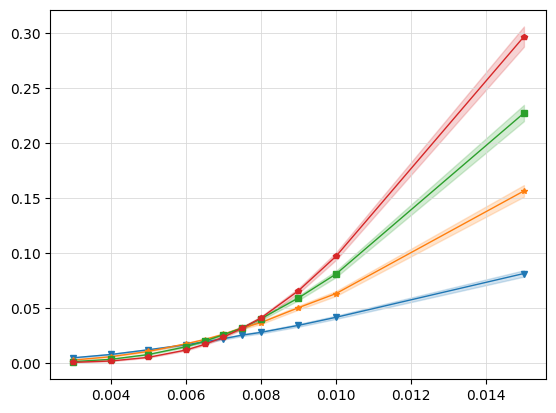

In [139]:
# PYMATCHING PLOT R_e = 0
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=pymatching_stats,
    x_func=lambda stats: stats.json_metadata["p"],
    group_func=group_func,
    # group_func=lambda stats: "d=" + str(stats.json_metadata["d"]),
    # + stats.json_metadata["decoder"]
    plot_args_func=plot_args,
)
ax.loglog()
ax.set_title(
    r"$\bf{Experiment 1:}$ Fault Tolerant Surface Code Threshold, Pauli Noise ($R_e$=0), decoder=PyMatching",
    fontdict=dict(fontsize=8),
)

ax.set_xlim(3e-3, 1.5e-2)
ax.set_ylim(5e-5, 5e-1)
ax.set_xlabel("Physical error rate: $p$", fontsize=8)
ax.set_ylabel("Logical error rate per shot: $P_L$", fontsize=8)
ax.grid(which="both")
# inset axes
axins = inset_axes(ax, width="45%", height="45%", loc="lower right", borderpad=1.5)
axins_ylim = (1e-2, 0.8e-1)
axins_xlim = (5.5e-3, 9e-3)
axins.set_ylim(*axins_ylim)
axins.set_xlim(*axins_xlim)

axins.loglog()
axins.grid(which="minor")
# Pull data from the main axes
for idx, line in enumerate(ax.lines):
    extras = dict()
    extras["alpha"] = 0.6
    axins.plot(
        line.get_xdata(),
        line.get_ydata(),
        color=line.get_color(),
        linestyle=line.get_linestyle(),
        marker=line.get_marker(),
        **extras,
    )
# Annotate pthresh points
pthr_lower = (5.70e-3, 1.5e-2)
axins.plot(
    pthr_lower[0],
    pthr_lower[1],
    "o",
    label="_nolegend_",
    fillstyle="none",
    markersize=10,
    color="xkcd:aqua",
)
axins.vlines(
    x=pthr_lower[0],
    ymin=0,
    ymax=pthr_lower[1],
    color="xkcd:aqua",
    linestyle="--",
    label="$p_{thr,lower}$" + f"$={pthr_lower[0]:.2E}$",
)
pthr_upper = (7.75e-3, 3.6e-2)
axins.plot(
    pthr_upper[0],
    pthr_upper[1],
    "o",
    label="_nolegend_",
    fillstyle="none",
    markersize=10,
    color="xkcd:bright magenta",
)
axins.vlines(
    x=pthr_upper[0],
    ymin=0,
    ymax=pthr_upper[1],
    color="xkcd:bright magenta",
    linestyle="--",
    label="$p_{thr,upper}$" + f"$={pthr_upper[0]:.2E}$",
)
# mark xticks on inset plot at pthr intercept
# axins.xaxis.set_major_locator(
#     ticker.FixedLocator([6e-3, 7e-3, 8e-3, pthr_lower[0], pthr_upper[0]])
# )
# zoomed region
mark_inset(ax, axins, loc1=3, loc2=1, fc="none", ec="grey", alpha=0.6, linewidth=1.5)
ax.legend(fontsize=8)
axins.legend(fontsize=8)
ax.tick_params(axis="both", which="both", labelsize=6)
axins.tick_params(axis="both", which="both", labelsize=5)
fig.set_dpi(FIG_DPI)
plt.savefig("../poster/images/pthr_experiment1.png", bbox_inches="tight", dpi=FIG_DPI)

In [ ]:
ABLATION_FILES = [
    "../datasets/circuit=surface_code:rotated_memory_x/decoder=mwpf/erasure=0.0/solver=SolverSerialJointSingleHair/2025-11-27_d=3.csv",
    "../datasets/circuit=surface_code:rotated_memory_x/decoder=mwpf/erasure=0.0/solver=SolverSerialJointSingleHair/2025-11-27_d=5.csv",
    "../datasets/circuit=surface_code:rotated_memory_x/decoder=mwpf/erasure=0.0/solver=SolverSerialJointSingleHair/2025-11-27_d=7.csv",
    "../datasets/circuit=surface_code:rotated_memory_x/decoder=mwpf/erasure=0.0/solver=SolverSerialJointSingleHair/2025-11-27_d=9.csv",
    "../datasets/circuit=surface_code:rotated_memory_x/decoder=SinterMWPFDecoder/erasure=0.0/solver=SolverSerialJointSingleHair/2025-11-30.csv",
]
ablation_stats = sinter.read_stats_from_csv_files(*ABLATION_FILES)
for s in ablation_stats:
    # the naming scheme in util.sinter_task.DecoderLib changed slightly since last run
    if s.json_metadata.get("decoder") == "SinterMWPFDecoder":
        s.json_metadata["decoder"] = "mwpf"

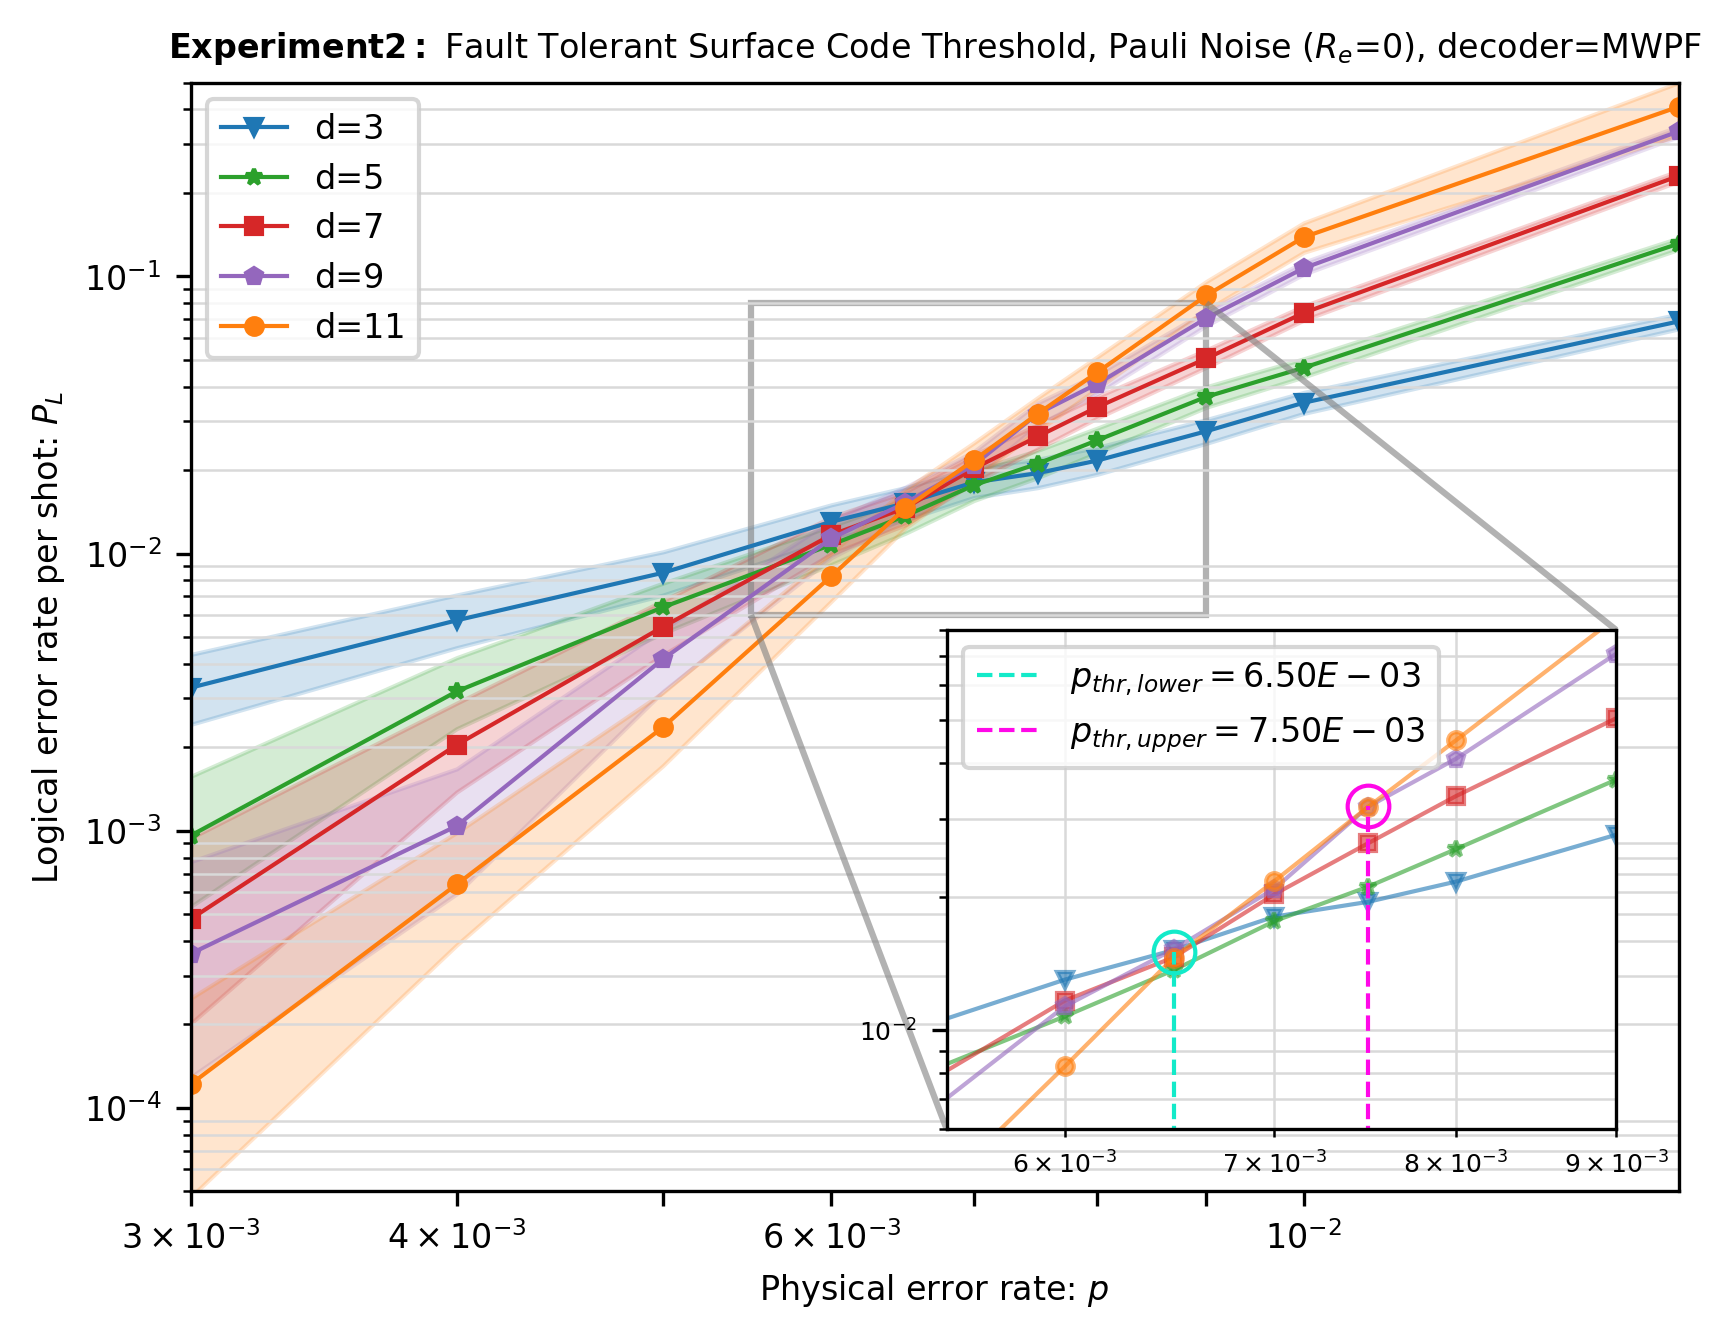

In [ ]:
# MWPF PLOT R_e = 0
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=ablation_stats,
    x_func=lambda stats: stats.json_metadata["p"],
    group_func=group_func,
    # + stats.json_metadata["decoder"]
    plot_args_func=plot_args,
)
ax.loglog()
ax.set_title(
    r"$\bf{Experiment 2:}$ Fault Tolerant Surface Code Threshold, Pauli Noise ($R_e$=0), decoder=MWPF",
    fontdict=dict(fontsize=8),
)
ax.set_ylim(5e-5, 5e-1)
ax.set_xlim(3e-3, 1.5e-2)
ax.set_xlabel("Physical error rate: $p$", fontsize=8)
ax.set_ylabel("Logical error rate per shot: $P_L$", fontsize=8)
ax.grid(which="major")
ax.grid(which="minor")

# inset axes
axins = inset_axes(ax, width="45%", height="45%", loc="lower right", borderpad=1.5)
axins_ylim = (6e-3, 0.8e-1)
axins_xlim = (5.5e-3, 9e-3)
axins.set_ylim(*axins_ylim)
axins.set_xlim(*axins_xlim)

axins.loglog()
axins.grid(which="minor")
# Pull data from the main axes
for idx, line in enumerate(ax.lines):
    extras = dict()
    extras["alpha"] = 0.6
    axins.plot(
        line.get_xdata(),
        line.get_ydata(),
        color=line.get_color(),
        linestyle=line.get_linestyle(),
        marker=line.get_marker(),
        **extras,
    )
# Annotate pthresh points
pthr_lower = (6.5e-3, 1.5e-2)
axins.plot(
    pthr_lower[0],
    pthr_lower[1],
    "o",
    label="_nolegend_",
    fillstyle="none",
    markersize=10,
    color="xkcd:aqua",
)
axins.vlines(
    x=pthr_lower[0],
    ymin=0,
    ymax=pthr_lower[1],
    color="xkcd:aqua",
    linestyle="--",
    label="$p_{thr,lower}$" + f"$={pthr_lower[0]:.2E}$",
)
pthr_upper = (7.5e-3, 3.2e-2)
axins.plot(
    pthr_upper[0],
    pthr_upper[1],
    "o",
    label="_nolegend_",
    fillstyle="none",
    markersize=10,
    color="xkcd:bright magenta",
)
axins.vlines(
    x=pthr_upper[0],
    ymin=0,
    ymax=pthr_upper[1],
    color="xkcd:bright magenta",
    linestyle="--",
    label="$p_{thr,upper}$" + f"$={pthr_upper[0]:.2E}$",
)
# mark xticks on inset plot at pthr intercept
# axins.xaxis.set_major_locator(
#     ticker.FixedLocator([6e-3, 7e-3, 8e-3, pthr_lower[0], pthr_upper[0]])
# )
axins.legend(fontsize=8)
# zoomed region
mark_inset(ax, axins, loc1=3, loc2=1, fc="none", ec="grey", alpha=0.6, linewidth=1.5)
ax.legend(fontsize=8)
axins.legend(fontsize=8)
ax.tick_params(axis="both", which="both", labelsize=8)
axins.tick_params(axis="both", which="both", labelsize=6)

ax.xaxis.set_major_locator(ticker.LogLocator(base=10, numticks=15, subs="all"))
fig.set_dpi(FIG_DPI)
plt.savefig("../poster/images/pthr_experiment2.png", bbox_inches="tight", dpi=FIG_DPI)

In [ ]:
ERASURE_FILES = [
    "../datasets/circuit=surface_code:rotated_memory_x/decoder=mwpf/erasure=1.0/solver=SolverSerialJointSingleHair/2025-11-28_d=3.csv",
    "../datasets/circuit=surface_code:rotated_memory_x/decoder=mwpf/erasure=1.0/solver=SolverSerialJointSingleHair/2025-11-28_d=5.csv",
    "../datasets/circuit=surface_code:rotated_memory_x/decoder=mwpf/erasure=1.0/solver=SolverSerialJointSingleHair/2025-11-28_d=7.csv",
    "../datasets/circuit=surface_code:rotated_memory_x/decoder=mwpf/erasure=1.0/solver=SolverSerialJointSingleHair/2025-11-28_d=9.csv",
    "../datasets/circuit=surface_code:rotated_memory_x/decoder=mwpf/erasure=1.0/solver=SolverSerialJointSingleHair/2025-11-28_d=11,p=0.01,0.02,0.03.csv",
    # "../datasets/circuit=surface_code:rotated_memory_x/decoder=mwpf/erasure=1.0/solver=SolverSerialJointSingleHair/2025-11-28_memfix4_d=7.csv",
    "../datasets/circuit=surface_code:rotated_memory_x/decoder=mwpf/erasure=1.0/solver=SolverSerialJointSingleHair/2025-11-28_memfix4_d=9.csv",
]

erasure_stats = sinter.read_stats_from_csv_files(*ERASURE_FILES)

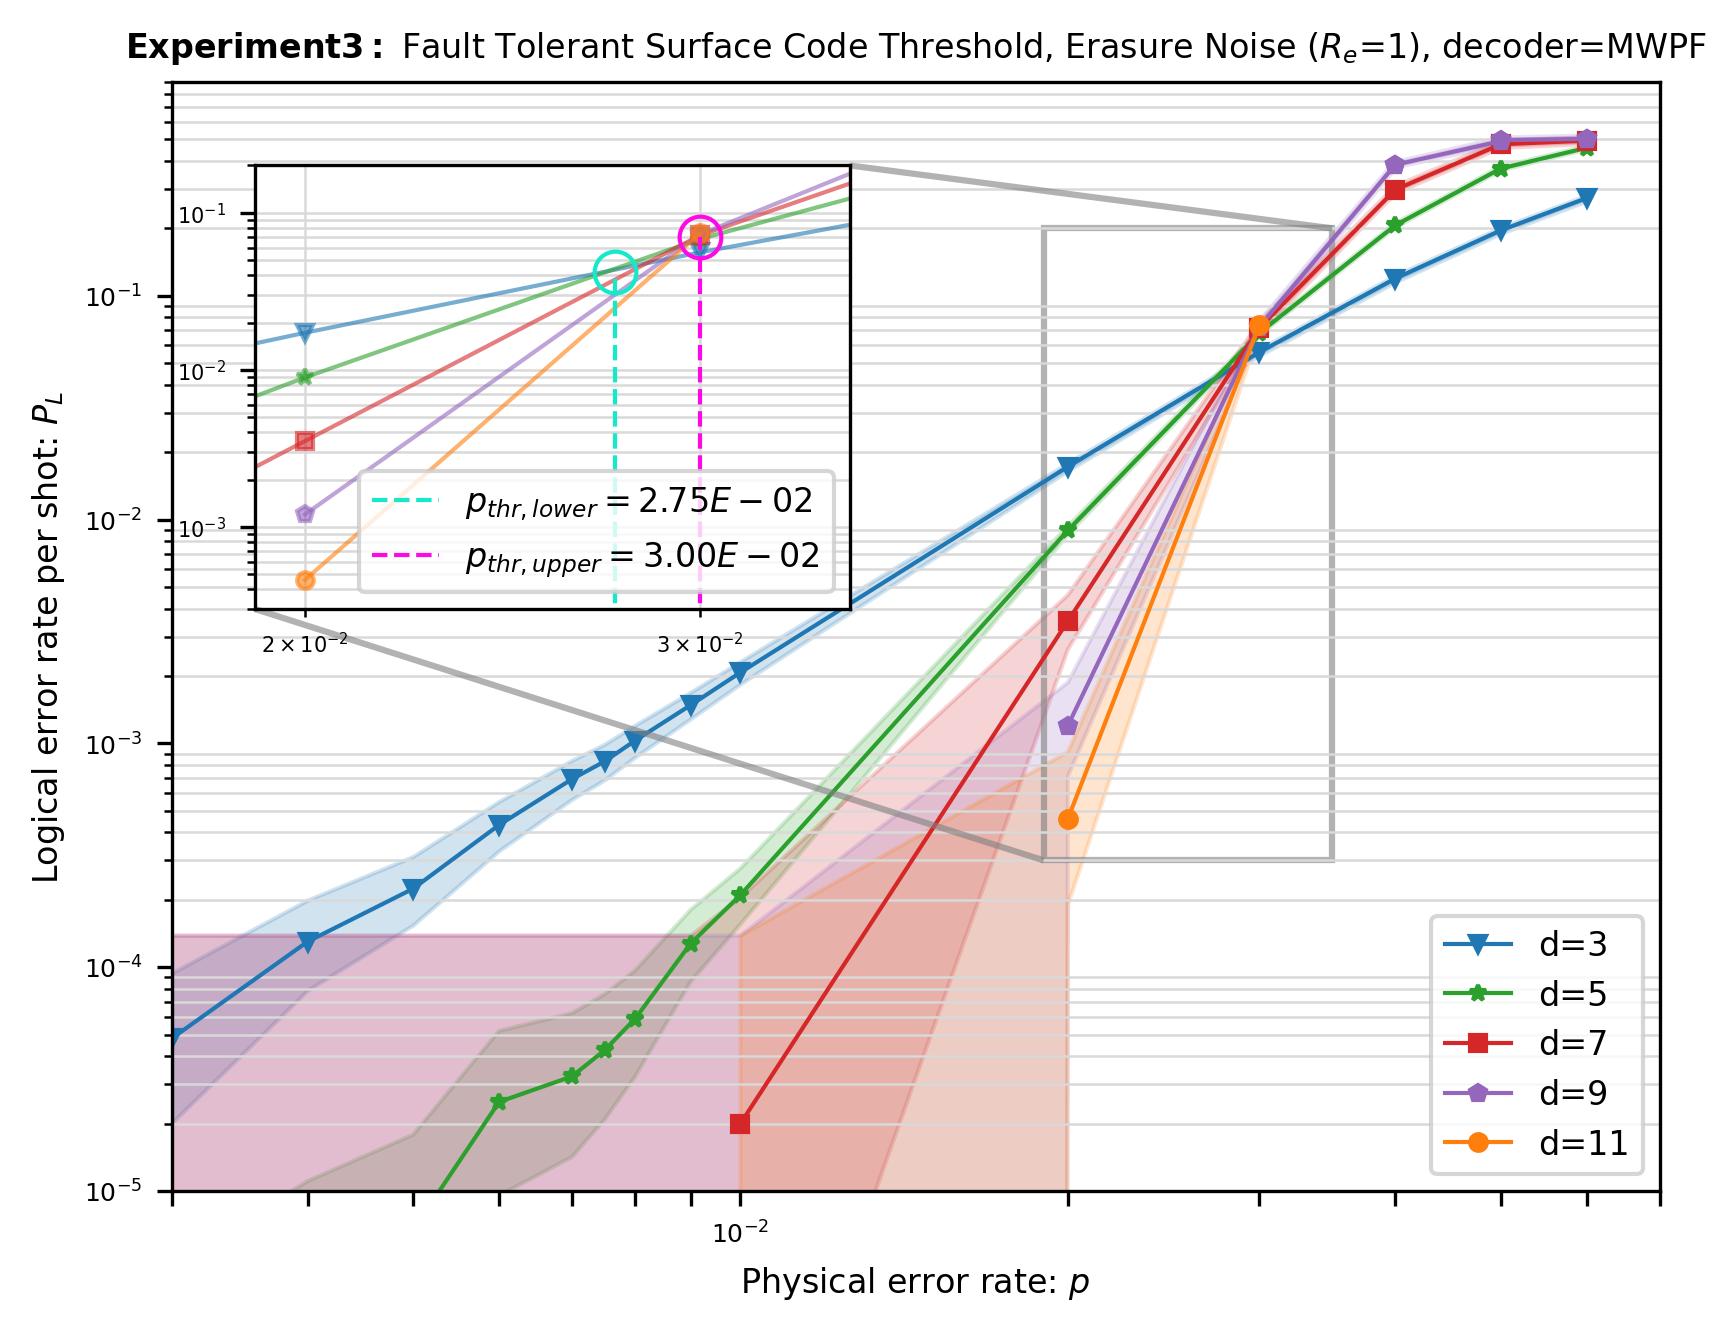

In [ ]:
# MWPF PLOT R_e = 1
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=erasure_stats,
    x_func=lambda stats: stats.json_metadata["p"],
    group_func=group_func,
    # + stats.json_metadata["decoder"]
    plot_args_func=plot_args,
)
ax.loglog()
ax.set_title(
    r"$\bf{Experiment 3:}$ Fault Tolerant Surface Code Threshold, Erasure Noise ($R_e$=1), decoder=MWPF",
    fontdict=dict(fontsize=8),
)

ax.set_xlim(3e-3, 7e-2)
ax.set_ylim(1e-5, 9e-1)
ax.set_xlabel("Physical error rate: $p$", fontsize=8)
ax.set_ylabel("Logical error rate per shot: $P_L$", fontsize=8)
ax.grid(which="both")

# inset axes
axins = inset_axes(ax, width="40%", height="40%", loc="upper left", borderpad=2)
axins_ylim = (3e-4, 2e-1)
axins_xlim = (1.9e-2, 3.5e-2)
axins.set_ylim(*axins_ylim)
axins.set_xlim(*axins_xlim)

axins.loglog()
axins.grid(which="minor")
# Pull data from the main axes
for idx, line in enumerate(ax.lines):
    extras = dict()
    extras["alpha"] = 0.6
    axins.plot(
        line.get_xdata(),
        line.get_ydata(),
        color=line.get_color(),
        linestyle=line.get_linestyle(),
        marker=line.get_marker(),
        **extras,
    )
# Annotate pthresh points
pthr_lower = (2.75e-2, 4.2e-2)
axins.plot(
    pthr_lower[0],
    pthr_lower[1],
    "o",
    label="_nolegend_",
    fillstyle="none",
    markersize=10,
    color="xkcd:aqua",
)
axins.vlines(
    x=pthr_lower[0],
    ymin=0,
    ymax=pthr_lower[1],
    color="xkcd:aqua",
    linestyle="--",
    label="$p_{thr,lower}$" + f"$={pthr_lower[0]:.2E}$",
)
pthr_upper = (3e-2, 7e-2)
axins.plot(
    pthr_upper[0],
    pthr_upper[1],
    "o",
    label="_nolegend_",
    fillstyle="none",
    markersize=10,
    color="xkcd:bright magenta",
)
axins.vlines(
    x=pthr_upper[0],
    ymin=0,
    ymax=pthr_upper[1],
    color="xkcd:bright magenta",
    linestyle="--",
    label="$p_{thr,upper}$" + f"$={pthr_upper[0]:.2E}$",
)
# mark xticks on inset plot at pthr intercept
# axins.xaxis.set_major_locator(
#     ticker.FixedLocator([6e-3, 7e-3, 8e-3, pthr_lower[0], pthr_upper[0]])
# )
# zoomed region
mark_inset(ax, axins, loc1=3, loc2=1, fc="none", ec="grey", alpha=0.6, linewidth=1.5)
ax.tick_params(axis="both", which="both", labelsize=6)
axins.tick_params(axis="both", which="both", labelsize=5)
ax.legend(fontsize=8, loc="lower right")
axins.legend(fontsize=8)
ax.xaxis.set_major_locator(ticker.LogLocator(base=10, numticks=15, subs="all"))
fig.set_dpi(FIG_DPI)
plt.savefig("../poster/images/pthr_experiment3.png", bbox_inches="tight", dpi=FIG_DPI)

In [ ]:
PYMATCHING_CUSTOM_FILES = [
    "../datasets/circuit=surface_code:rotated_memory_x/decoder=HeraldedEraseDecoder/erasure=1.0/2025-11-30_pthresh.csv"
]
custom_stats = sinter.read_stats_from_csv_files(*PYMATCHING_CUSTOM_FILES)

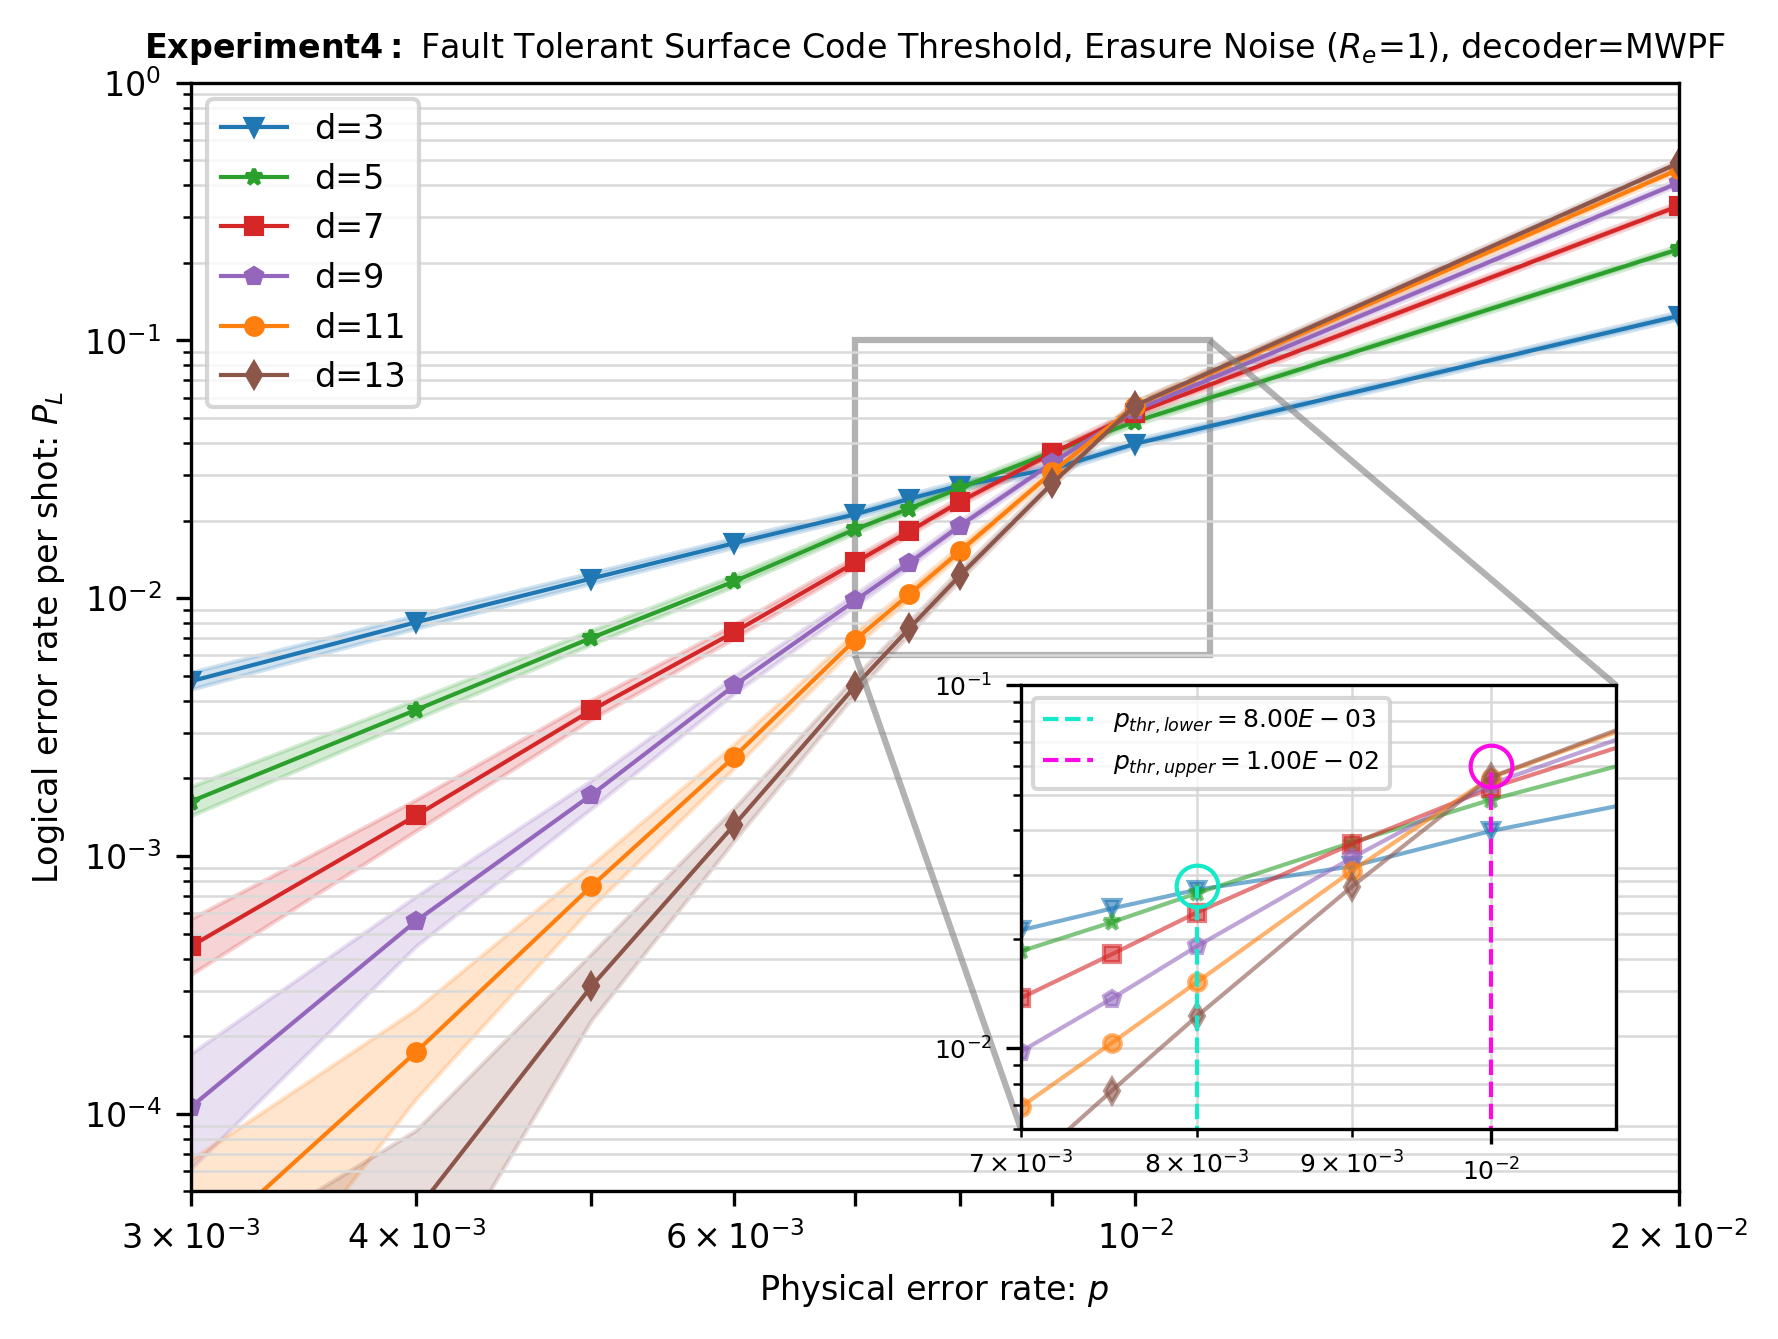

In [ ]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=custom_stats,
    x_func=lambda stats: stats.json_metadata["p"],
    group_func=group_func,
    # + stats.json_metadata["decoder"]
    plot_args_func=plot_args,
)
ax.loglog()
ax.set_title(
    r"$\bf{Experiment 4:}$ Fault Tolerant Surface Code Threshold, Erasure Noise ($R_e$=1), decoder=MWPF",
    fontdict=dict(fontsize=8),
)
ax.set_ylim(5e-5, 1e0)
ax.set_xlim(3e-3, 2e-2)
ax.set_xlabel("Physical error rate: $p$", fontsize=8)
ax.set_ylabel("Logical error rate per shot: $P_L$", fontsize=8)
ax.grid(which="major")
ax.grid(which="minor")

# inset axes
axins = inset_axes(ax, width="40%", height="40%", loc="lower right", borderpad=1.5)
axins_ylim = (6e-3, 1e-1)
axins_xlim = (7e-3, 1.1e-2)
axins.set_ylim(*axins_ylim)
axins.set_xlim(*axins_xlim)

axins.loglog()
axins.grid(which="minor")
# Pull data from the main axes
for idx, line in enumerate(ax.lines):
    extras = dict()
    extras["alpha"] = 0.6
    axins.plot(
        line.get_xdata(),
        line.get_ydata(),
        color=line.get_color(),
        linestyle=line.get_linestyle(),
        marker=line.get_marker(),
        **extras,
    )
# Annotate pthresh points
pthr_lower = (8e-3, 2.8e-2)
axins.plot(
    pthr_lower[0],
    pthr_lower[1],
    "o",
    label="_nolegend_",
    fillstyle="none",
    markersize=10,
    color="xkcd:aqua",
)
axins.vlines(
    x=pthr_lower[0],
    ymin=0,
    ymax=pthr_lower[1],
    color="xkcd:aqua",
    linestyle="--",
    label="$p_{thr,lower}$" + f"$={pthr_lower[0]:.2E}$",
)
pthr_upper = (1e-2, 6e-2)
axins.plot(
    pthr_upper[0],
    pthr_upper[1],
    "o",
    label="_nolegend_",
    fillstyle="none",
    markersize=10,
    color="xkcd:bright magenta",
)
axins.vlines(
    x=pthr_upper[0],
    ymin=0,
    ymax=pthr_upper[1],
    color="xkcd:bright magenta",
    linestyle="--",
    label="$p_{thr,upper}$" + f"$={pthr_upper[0]:.2E}$",
)
# mark xticks on inset plot at pthr intercept
# axins.xaxis.set_major_locator(
#     ticker.FixedLocator([6e-3, 7e-3, 8e-3, pthr_lower[0], pthr_upper[0]])
# )
axins.legend(fontsize=8)
# zoomed region
mark_inset(ax, axins, loc1=3, loc2=1, fc="none", ec="grey", alpha=0.6, linewidth=1.5)
ax.legend(fontsize=8)
axins.legend(fontsize=6)
ax.tick_params(axis="both", which="both", labelsize=8)
axins.tick_params(axis="both", which="both", labelsize=6)

ax.xaxis.set_major_locator(ticker.LogLocator(base=10, numticks=15, subs="all"))
fig.set_dpi(FIG_DPI)
plt.savefig("../poster/images/pthr_experiment4.png", bbox_inches="tight", dpi=FIG_DPI)

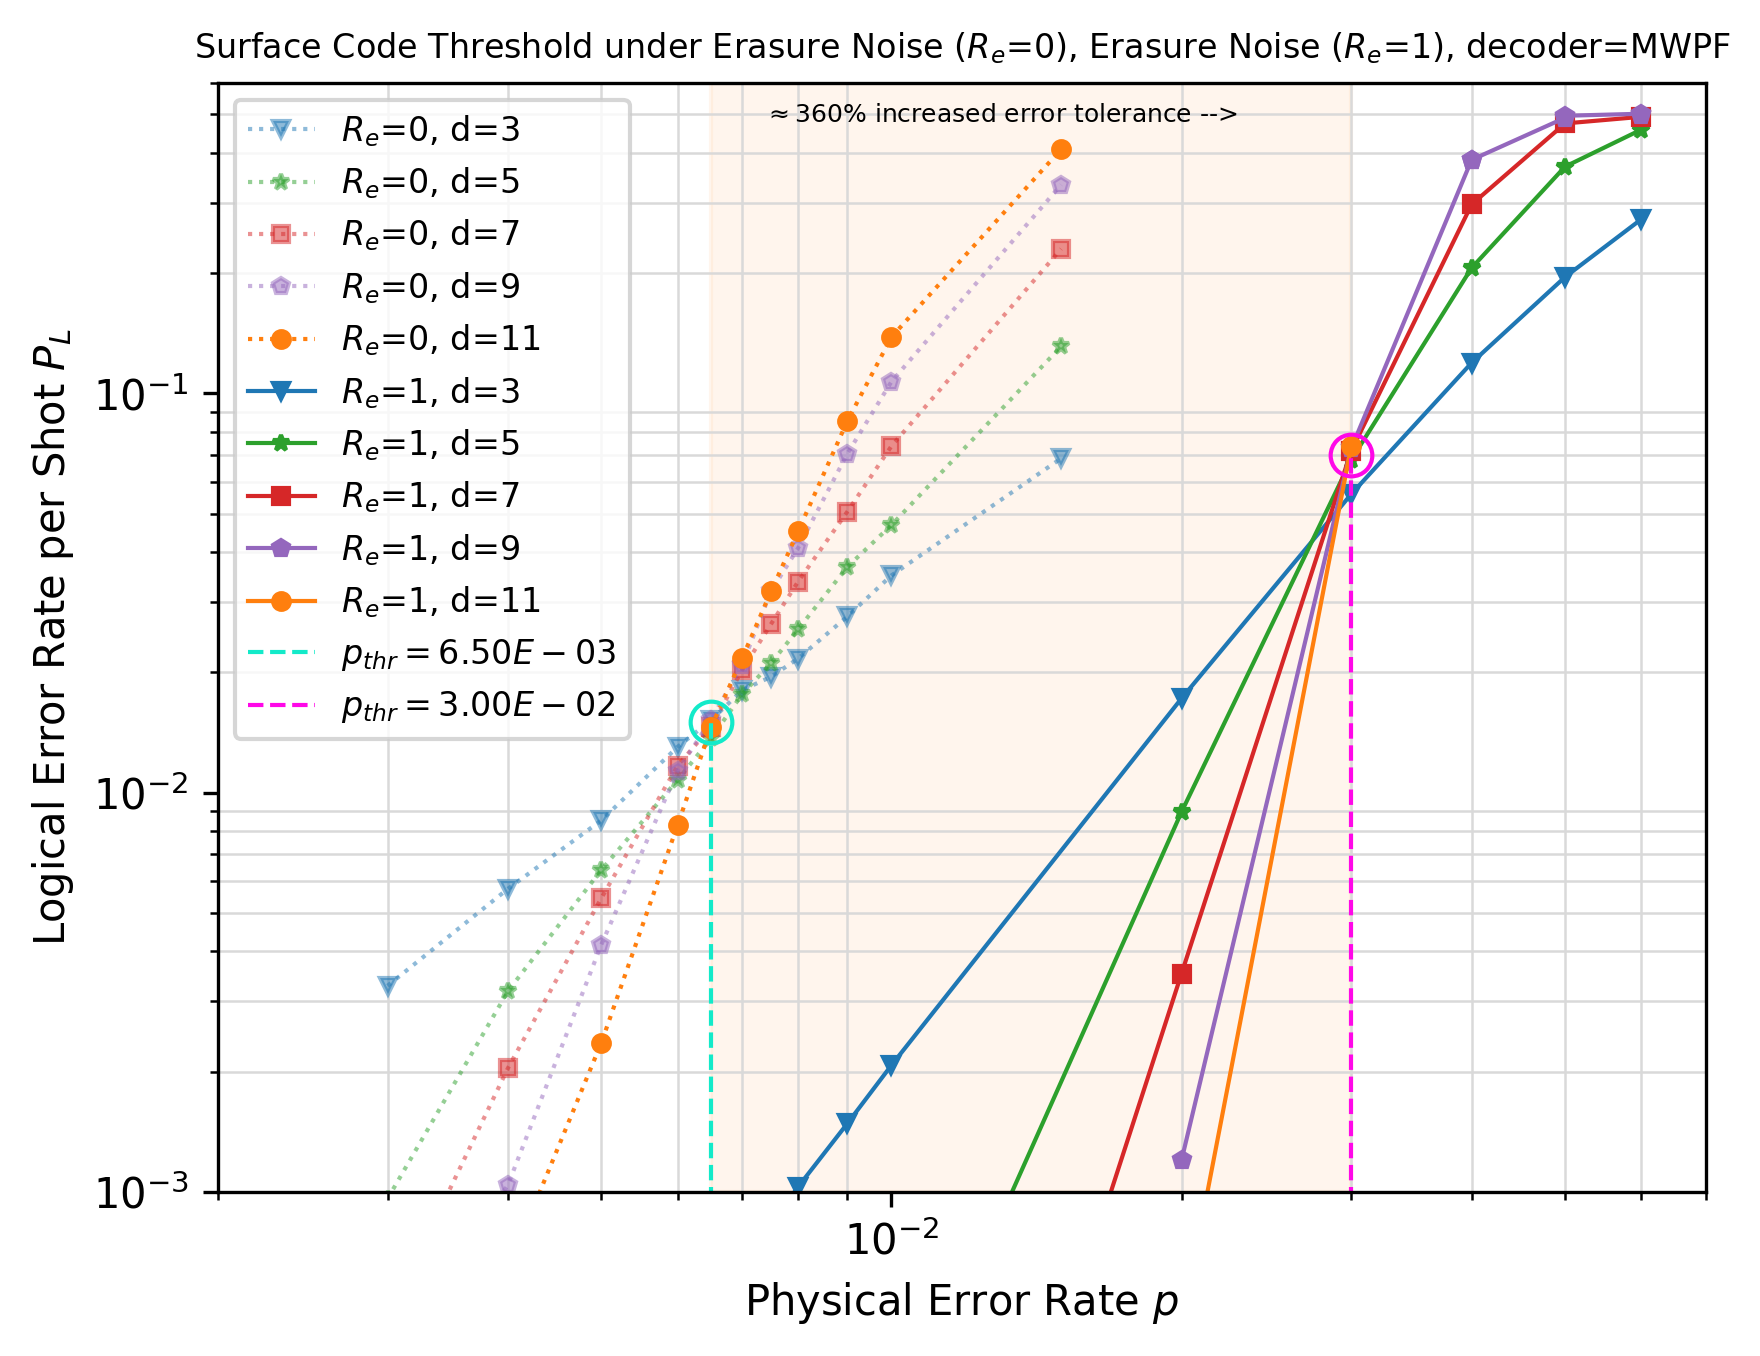

In [ ]:
# combined

fig, ax = plt.subplots(1, 1)


def filter_func(stats):
    # filter d=3,5,7,9 to avoid cluttering the plot
    return stats.json_metadata.get("d") in [3, 5, 7, 9, 11]


def get_colors(d, decoder):
    return colors[d]


def comb_plot_args(index, curve_id):
    result = dict(
        marker=curve_id.get("marker"),
        color=curve_id.get("color"),
        linestyle=curve_id.get("linestyle"),
    )
    if index < 4:
        result["alpha"] = 0.5
    return result


# def group_func(stats):
#     decoder = stats.json_metadata.get("decoder")
#     R_e = bool(stats.json_metadata.get("p_erase"))
#     d = stats.json_metadata.get("d")
#     label = f"{decoder}, d={d}"
#     result = dict(
#         label=label,
#         marker=get_marker(d),
#         color=get_colors(d, decoder),
#         sort=decoder + str(d),
#     )
#     if decoder == "pymatching":
#         result["linestyle"] = "."
#         result["label"] = result["label"] + ", $R_e=0$"
#     if decoder == "mwpf":
#         result["linestyle"] = "-"
#         if R_e:
#             result["label"] = result["label"] + ", $R_e=1$"
#         else:
#             result["label"] = result["label"] + ", $R_e=1$"
#     if decoder == "HeraldedEraseDecoder":
#         result["linestyle"] = "."
#     return result


def group_func(stats):
    decoder = stats.json_metadata.get("decoder")
    R_e = int(bool(stats.json_metadata.get("p_erase")))
    d = stats.json_metadata.get("d")
    label = f"$R_e$={R_e}, d={d}"
    result = dict(
        label=label,
        marker=get_marker(d),
        color=get_colors(d, decoder),
        sort=int(R_e) * 100 + d,
    )
    if decoder == "pymatching":
        result["linestyle"] = "."
        result["label"] = result["label"] + ", $R_e=0$"
    if decoder == "mwpf":
        # result["linestyle"] = "-"
        if R_e == 1:
            result["linestyle"] = "-"
        else:
            result["linestyle"] = ":"
    if decoder == "HeraldedEraseDecoder":
        result["linestyle"] = "."
    return result


sinter.plot_error_rate(
    ax=ax,
    stats=ablation_stats + erasure_stats,
    x_func=lambda stats: stats.json_metadata["p"],
    group_func=group_func,
    highlight_max_likelihood_factor=1,
    filter_func=filter_func,
    plot_args_func=comb_plot_args,
)
ax.loglog()
ax.set_ylim(1e-3, 6e-1)
ax.set_xlim(2e-3, 0.7e-1)
ax.set_title(
    r"Surface Code Threshold under Erasure Noise ($R_e$=0), Erasure Noise ($R_e$=1), decoder=MWPF",
    fontdict=dict(fontsize=8),
)

ax.set_xlabel("Physical Error Rate $p$")
ax.set_ylabel("Logical Error Rate per Shot $P_L$")
ax.grid(which="major")
ax.grid(which="minor")

pthr_lower = (6.5e-3, 1.5e-2)
ax.plot(
    pthr_lower[0],
    pthr_lower[1],
    "o",
    label="_nolegend_",
    fillstyle="none",
    markersize=10,
    color="xkcd:aqua",
)
ax.vlines(
    x=pthr_lower[0],
    ymin=0,
    ymax=pthr_lower[1],
    color="xkcd:aqua",
    linestyle="--",
    label="$p_{thr}$" + f"$={pthr_lower[0]:.2E}$",
)
pthr_upper = (3e-2, 7e-2)
ax.plot(
    pthr_upper[0],
    pthr_upper[1],
    "o",
    label="_nolegend_",
    fillstyle="none",
    markersize=10,
    color="xkcd:bright magenta",
)
ax.vlines(
    x=pthr_upper[0],
    ymin=0,
    ymax=pthr_upper[1],
    color="xkcd:bright magenta",
    linestyle="--",
    label="$p_{thr}$" + f"$={pthr_upper[0]:.2E}$",
)
ax.legend(fontsize=8)
axins.legend(fontsize=8)

ax.axvspan(pthr_lower[0], pthr_upper[0], color="peachpuff", alpha=0.25)
ax.text(
    1.3e-2,
    5e-1,
    r"$\approx 360\%$ increased error tolerance -->",
    ha="center",
    va="center",
    fontsize=6,
)
fig.set_dpi(FIG_DPI)
plt.savefig("../poster/images/pthr_best_summary.png", bbox_inches="tight", dpi=FIG_DPI)